In [125]:
%pip install seaborn
import seaborn as sns



In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv("Diabetes_type2raw.csv")
print(df.head(10))

               Name  Gender  BP(Systolic)  BP(Diastolic) Physical_Activity  \
0     Michael Jones    Male         140.0           90.0               Low   
1      Sandra Green  Female         110.0           80.0               Low   
2    Jennifer Lewis  Female         120.0           80.0            Medium   
3   Ronald Gonzalez    Male         130.0           85.0               Low   
4   Ashley Mitchell  Female         110.0           75.0               Low   
5      Andrew Smith    Male         100.0           80.0              High   
6     Matthew Lewis    Male         110.0           80.0              High   
7      Melissa Hill  Female          90.0           65.0               Low   
8   Patricia Walker  Female         110.0           70.0              High   
9  Joseph Hernandez    Male         140.0           80.0               Low   

    Age        BMI  DiabetesPedigreeFunction  Insulin  Skin Thickness(mm)  \
0  50.0  22.263762                       0.0     92.3           

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      1021 non-null   object 
 1   Gender                    1019 non-null   object 
 2   BP(Systolic)              1007 non-null   float64
 3   BP(Diastolic)             994 non-null    float64
 4   Physical_Activity         1019 non-null   object 
 5   Age                       998 non-null    float64
 6   BMI                       988 non-null    float64
 7   DiabetesPedigreeFunction  1016 non-null   float64
 8   Insulin                   1058 non-null   float64
 9   Skin Thickness(mm)        984 non-null    float64
 10  Glucose                   992 non-null    float64
 11  Type 2 Diabetes           1065 non-null   int64  
dtypes: float64(8), int64(1), object(3)
memory usage: 87.4+ KB


In [128]:
df.describe()

,BP(Systolic),BP(Diastolic),Age,BMI,DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose,Type 2 Diabetes
count,1007.000000,994.000000,998.000000,988.000000,1016.000000,1058.000000,984.000000,992.000000,1065.000000
mean,119.520357,79.377264,44.600200,25.252245,1.497047,131.624953,307.443252,137.930544,0.507981
std,14.272112,11.865202,12.700685,3.818955,1.568781,76.458035,34.685654,64.395257,0.500171
min,80.000000,0.000000,21.000000,17.183204,0.000000,0.000000,29.210000,50.000000,0.000000
25%,110.000000,70.000000,35.000000,22.650587,0.000000,65.400000,286.385000,80.000000,0.000000
50%,120.000000,80.000000,44.000000,24.603224,1.000000,118.200000,304.800000,128.500000,1.000000
75%,130.000000,80.000000,54.000000,27.492665,2.000000,198.400000,330.200000,177.250000,1.000000
max,180.000000,120.000000,86.000000,37.442807,8.000000,274.800000,406.400000,450.000000,1.000000


In [129]:
print(df.isnull().sum())

Name                        44
Gender                      46
BP(Systolic)                58
BP(Diastolic)               71
Physical_Activity           46
Age                         67
BMI                         77
DiabetesPedigreeFunction    49
Insulin                      7
Skin Thickness(mm)          81
Glucose                     73
Type 2 Diabetes              0
dtype: int64


In [130]:
numerical_columns = [ "BP(Systolic)","BP(Diastolic)","Age", "BMI","DiabetesPedigreeFunction","Skin Thickness(mm)","Insulin","Glucose"]  

df[numerical_columns] =df[numerical_columns].astype(float)
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())
print(df)

                 Name  Gender  BP(Systolic)  BP(Diastolic) Physical_Activity  \
0       Michael Jones    Male         140.0           90.0               Low   
1        Sandra Green  Female         110.0           80.0               Low   
2      Jennifer Lewis  Female         120.0           80.0            Medium   
3     Ronald Gonzalez    Male         130.0           85.0               Low   
4     Ashley Mitchell  Female         110.0           75.0               Low   
...               ...     ...           ...            ...               ...   
1060    Joseph Miller    Male         120.0           70.0               Low   
1061   James Williams    Male         120.0           80.0               Low   
1062  Sandra Robinson  Female         100.0           70.0              High   
1063              NaN  Female         120.0           80.0            Medium   
1064       John Davis    Male         110.0           60.0            Medium   

       Age        BMI  DiabetesPedigree

In [131]:
print(df.isnull().sum())


Name                        44
Gender                      46
BP(Systolic)                 0
BP(Diastolic)                0
Physical_Activity           46
Age                          0
BMI                          0
DiabetesPedigreeFunction     0
Insulin                      0
Skin Thickness(mm)           0
Glucose                      0
Type 2 Diabetes              0
dtype: int64


In [132]:
Categorical_columns = ["Gender", "Physical_Activity"]  

df[Categorical_columns] = df[Categorical_columns].fillna(df[Categorical_columns].mode().iloc[0])
print(df.isnull().sum())

Name                        44
Gender                       0
BP(Systolic)                 0
BP(Diastolic)                0
Physical_Activity            0
Age                          0
BMI                          0
DiabetesPedigreeFunction     0
Insulin                      0
Skin Thickness(mm)           0
Glucose                      0
Type 2 Diabetes              0
dtype: int64


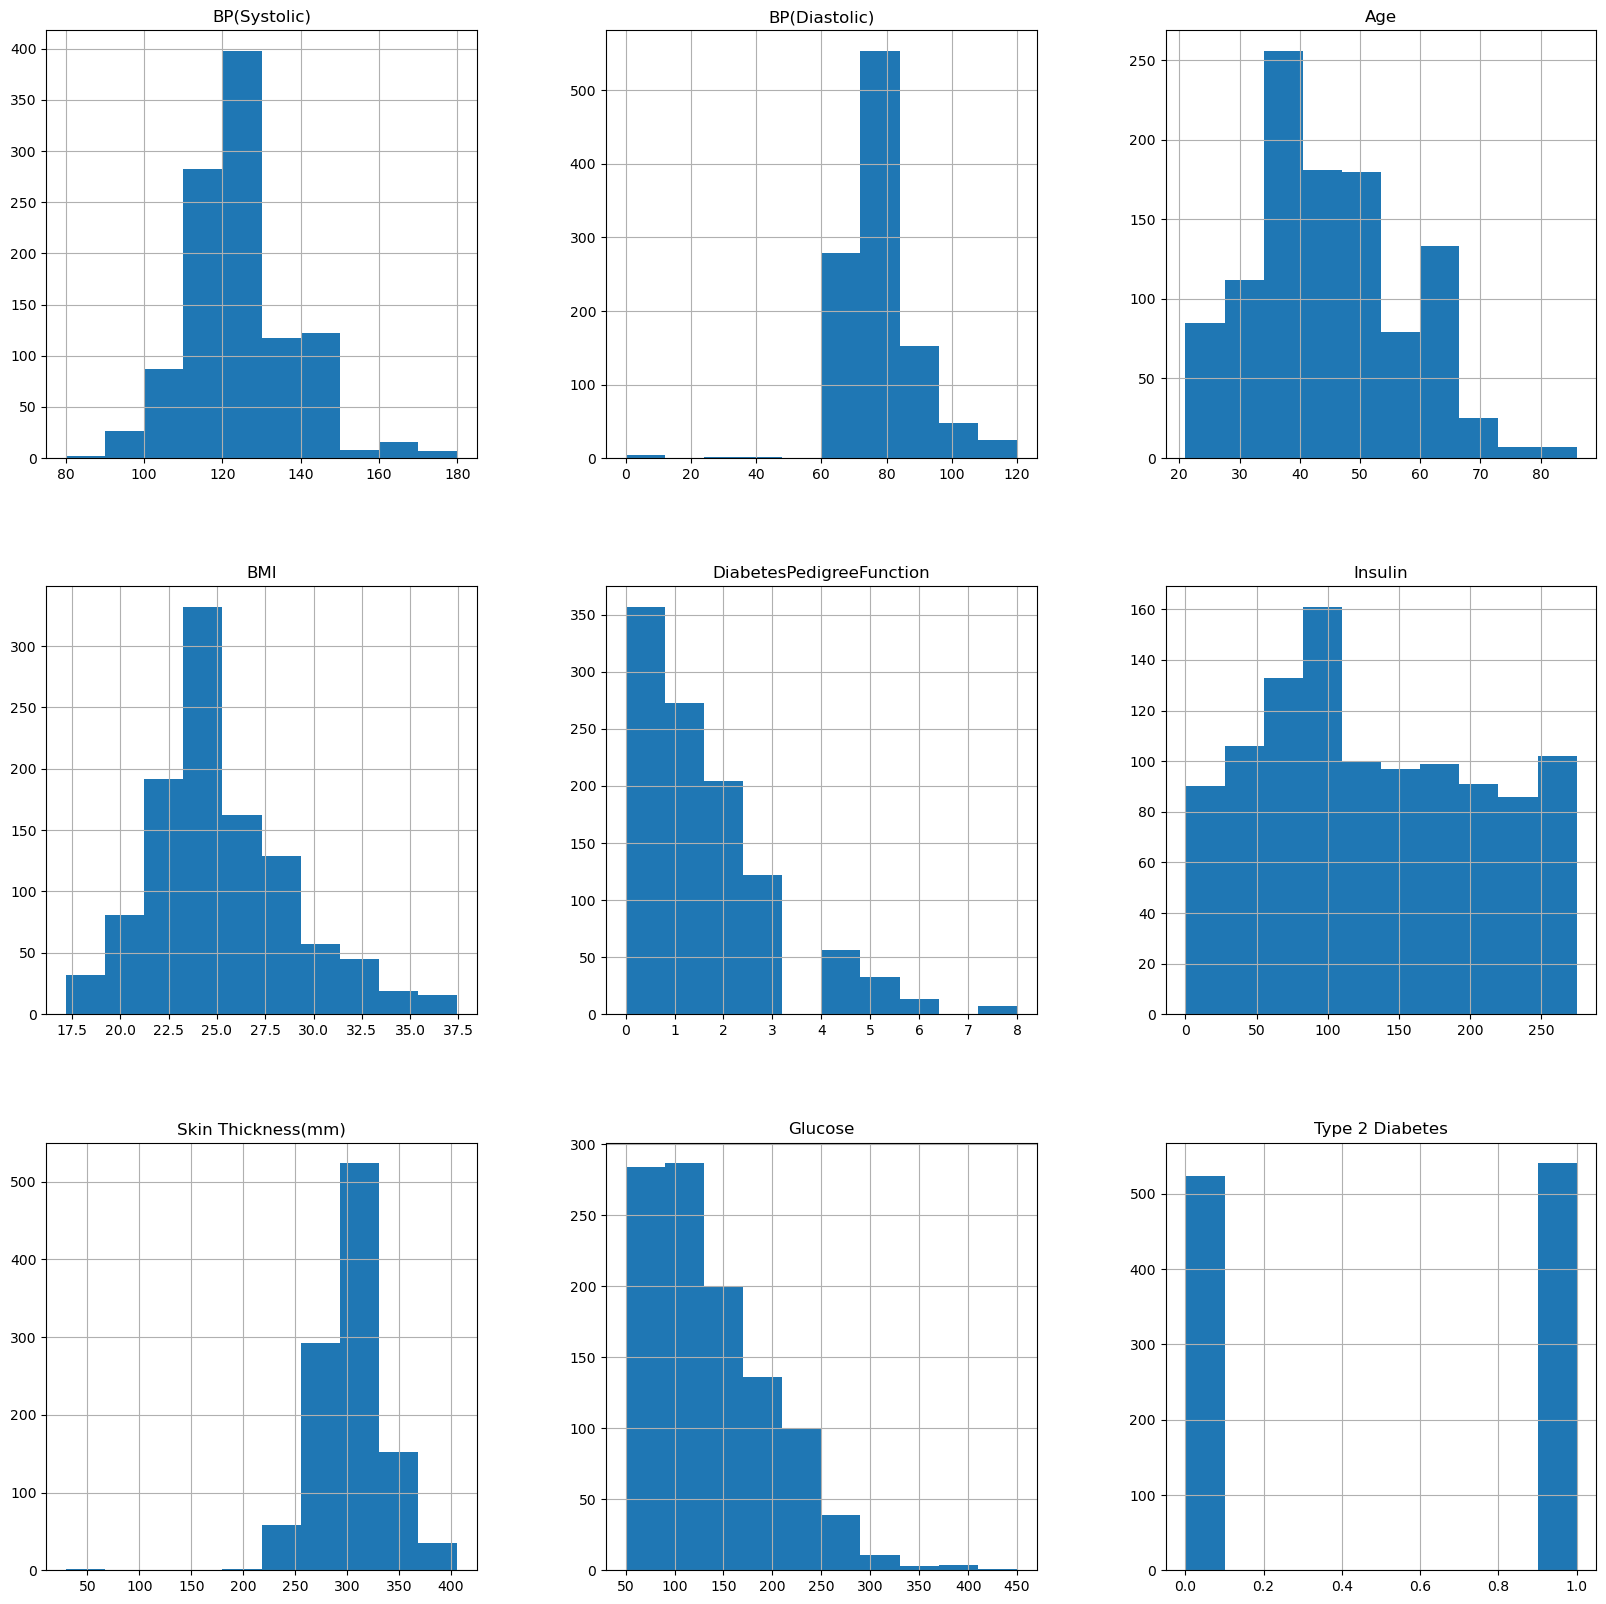

In [133]:
p=df.hist(figsize=(20,20))

In [134]:
for column in Categorical_columns :
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
print(df.head(10))

               Name  Gender  BP(Systolic)  BP(Diastolic)  Physical_Activity  \
0     Michael Jones       1         140.0           90.0                  1   
1      Sandra Green       0         110.0           80.0                  1   
2    Jennifer Lewis       0         120.0           80.0                  2   
3   Ronald Gonzalez       1         130.0           85.0                  1   
4   Ashley Mitchell       0         110.0           75.0                  1   
5      Andrew Smith       1         100.0           80.0                  0   
6     Matthew Lewis       1         110.0           80.0                  0   
7      Melissa Hill       0          90.0           65.0                  1   
8   Patricia Walker       0         110.0           70.0                  0   
9  Joseph Hernandez       1         140.0           80.0                  1   

    Age        BMI  DiabetesPedigreeFunction  Insulin  Skin Thickness(mm)  \
0  50.0  22.263762                       0.0     92.3

In [135]:
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
print(df.head(10))

               Name  Gender  BP(Systolic)  BP(Diastolic)  Physical_Activity  \
0     Michael Jones       1      1.474492       0.923466                  1   
1      Sandra Green       0     -0.688204       0.050725                  1   
2    Jennifer Lewis       0      0.032694       0.050725                  2   
3   Ronald Gonzalez       1      0.753593       0.487096                  1   
4   Ashley Mitchell       0     -0.688204      -0.385645                  1   
5      Andrew Smith       1     -1.409103       0.050725                  0   
6     Matthew Lewis       1     -0.688204       0.050725                  0   
7      Melissa Hill       0     -2.130002      -1.258385                  1   
8   Patricia Walker       0     -0.688204      -0.822015                  0   
9  Joseph Hernandez       1      1.474492       0.050725                  1   

        Age       BMI  DiabetesPedigreeFunction   Insulin  Skin Thickness(mm)  \
0  0.442459 -0.799274                 -0.960346 -

In [136]:
print(df.columns)

Index(['Name', 'Gender', 'BP(Systolic)', 'BP(Diastolic)', 'Physical_Activity',
       'Age', 'BMI', 'DiabetesPedigreeFunction', 'Insulin',
       'Skin Thickness(mm)', 'Glucose', 'Type 2 Diabetes'],
      dtype='object')


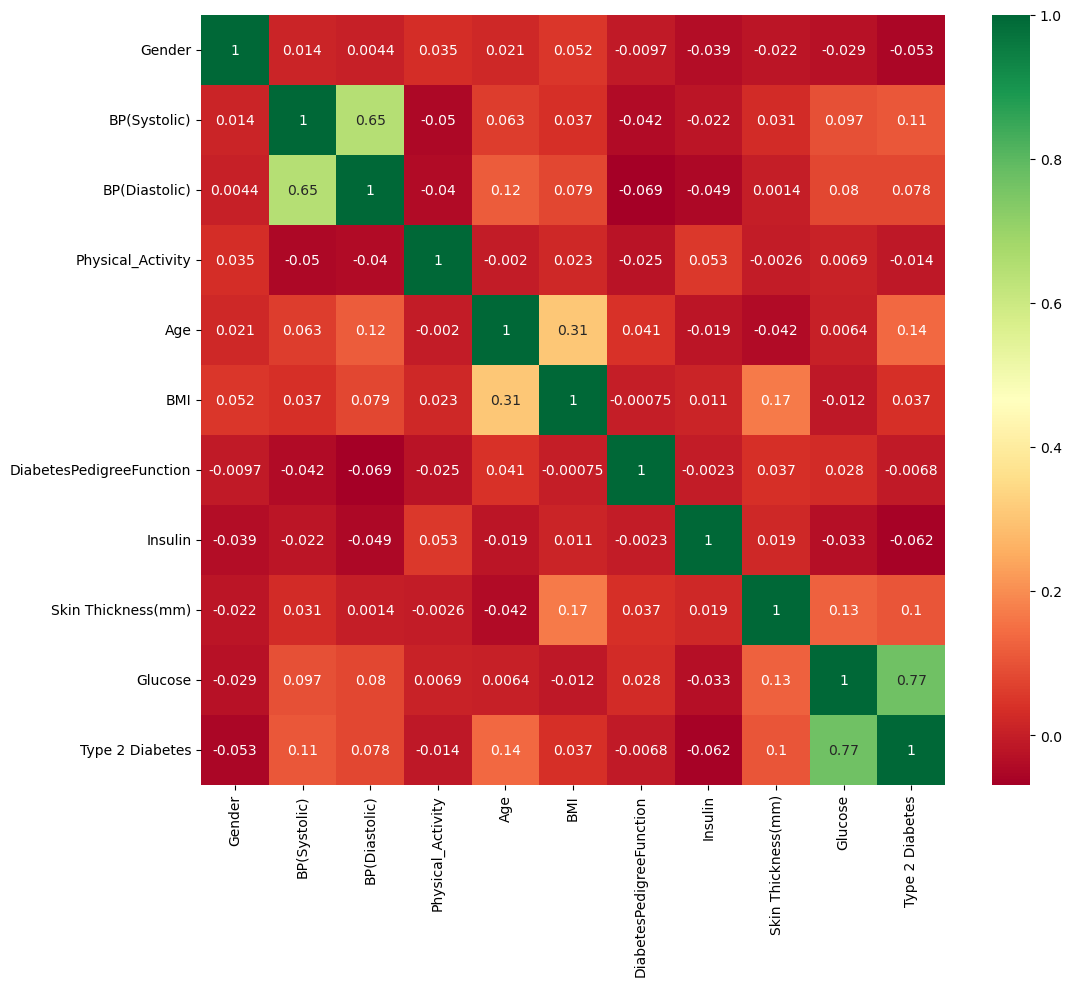

In [137]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.show()